In [4]:
import os
import pandas

folder_path = r"C:\Users\MainUser\cs230\BernsteinMartingaleNet\MarketData\historical_data"
date_str = "20201006"
data = pandas.read_csv(os.path.join(folder_path, f"spy_1min_{date_str}" + ".csv"))
data.tail()

,ts_recv,price,bid_px_00,ask_px_00,bid_sz_00,ask_sz_00,weighted_mid,rv_60s,ret_60s
954,2020-10-06 23:55:00+00:00,334.76,334.68,334.71,100,10000,334.680297,7.126842e-09,0.000058
955,2020-10-06 23:56:00+00:00,334.71,334.70,334.71,1090,9637,334.701016,7.190422e-09,-0.000074
956,2020-10-06 23:57:00+00:00,334.68,334.64,334.68,500,100,334.673333,8.726578e-09,-0.000096
957,2020-10-06 23:58:00+00:00,334.65,334.63,334.65,600,200,334.645000,6.851614e-09,0.000041
958,2020-10-06 23:59:00+00:00,334.66,334.65,334.67,800,1200,334.658000,8.530291e-08,-0.000150


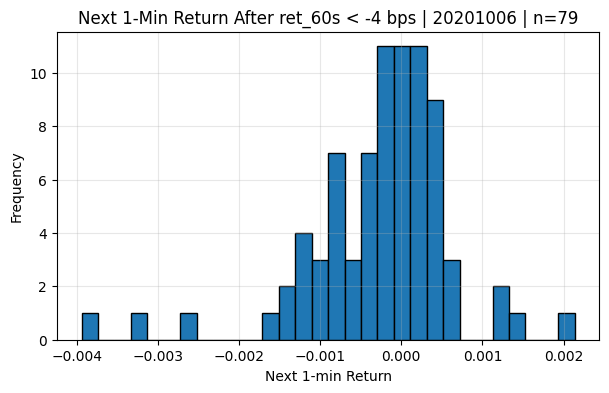

In [36]:
import matplotlib.pyplot as plt

df = data.copy()
df = df.sort_values("ts_recv").reset_index(drop=True)

lb = -0.0004
idx = df.index[df["ret_60s"] < lb]
idx = idx[idx + 1 < len(df)]

next_returns = df.loc[idx + 1, "ret_60s"].dropna()

plt.figure(figsize=(7, 4))
plt.hist(next_returns, bins=30, edgecolor="black")
plt.title(f"Next 1-Min Return After ret_60s < {lb*1e4:.0f} bps | {date_str} | n={len(idx)}")
plt.xlabel("Next 1-min Return")
plt.ylabel("Frequency")
plt.grid(alpha=0.3)
plt.show()

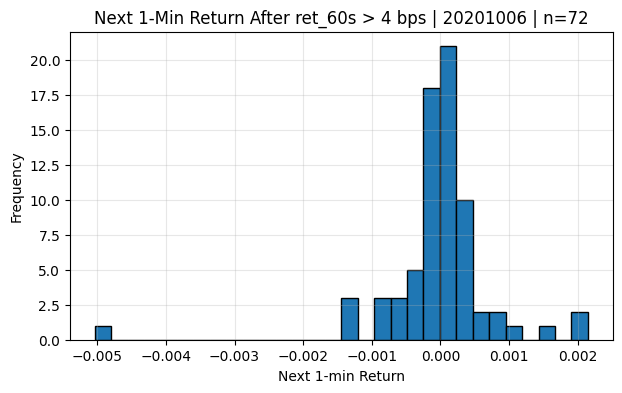

In [37]:
import matplotlib.pyplot as plt

df = data.copy()
df = df.sort_values("ts_recv").reset_index(drop=True)

ub = 0.0004
idx = df.index[df["ret_60s"] > ub]
idx = idx[idx + 1 < len(df)]

next_returns = df.loc[idx + 1, "ret_60s"].dropna()

plt.figure(figsize=(7, 4))
plt.hist(next_returns, bins=30, edgecolor="black")
plt.title(f"Next 1-Min Return After ret_60s > {ub*1e4:.0f} bps | {date_str} | n={len(idx)}")
plt.xlabel("Next 1-min Return")
plt.ylabel("Frequency")
plt.grid(alpha=0.3)
plt.show()

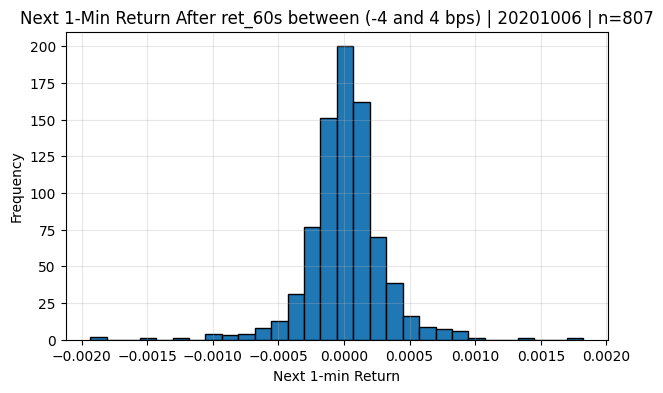

In [39]:
import matplotlib.pyplot as plt

df = data.copy()
df = df.sort_values("ts_recv").reset_index(drop=True)

idx = df.index[(df["ret_60s"] < ub) & (df["ret_60s"] > lb)]
idx = idx[idx + 1 < len(df)]

next_returns = df.loc[idx + 1, "ret_60s"].dropna()

plt.figure(figsize=(7, 4))
plt.hist(next_returns, bins=30, edgecolor="black")
plt.title(f"Next 1-Min Return After ret_60s between ({lb*1e4:.0f} and {ub*1e4:.0f} bps) | {date_str} | n={len(idx)}")
plt.xlabel("Next 1-min Return")
plt.ylabel("Frequency")
plt.grid(alpha=0.3)
plt.show()